In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tarekmasryo/hospital-deterioration-dataset")

print("Path to dataset files:", path)

100%|██████████| 40.2M/40.2M [00:00<00:00, 117MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tarekmasryo/hospital-deterioration-dataset/versions/1


In [ ]:
from pathlib import Path
import os
import zipfile

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 42
TARGET = "deterioration_next_12h"

PRIMARY_COLOR = "#2563EB"
SECONDARY_COLOR = "#F97316"
DANGER_COLOR = "#DC2626"
SUCCESS_COLOR = "#16A34A"
NEUTRAL_COLOR = "#64748B"
GRID_COLOR = "#E5E7EB"

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.4f}".format)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.alpha": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.frameon": False,
})
with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:

    print(os.listdir('/content/'))

    REQUIRED_FILES = [
    "patients.csv",
    "vitals_timeseries.csv",
    "labs_timeseries.csv",
    "hospital_deterioration_hourly_panel.csv",
    "hospital_deterioration_ml_ready.csv",
]

def find_data_dir(required_files=REQUIRED_FILES):
    candidate_roots = []

    env_data_dir = os.environ.get("DATA_DIR")
    if env_data_dir:
        candidate_roots.append(Path(env_data_dir))

    candidate_roots.extend([
        Path("/kaggle/input"),
        Path("data/raw"),
        Path("."),
    ])

    checked_roots = []
    for root in candidate_roots:
        root = root.expanduser().resolve() if root.exists() else root
        if not root.exists():
            continue

        checked_roots.append(str(root))

        if all((root / file_name).exists() for file_name in required_files):
            return root

        for first_file in root.rglob(required_files[0]):
            candidate = first_file.parent
            if all((candidate / file_name).exists() for file_name in required_files):
                return candidate

    raise FileNotFoundError(
        "Could not find the dataset files. Checked roots: "
        + ", ".join(checked_roots)
    )

DATA_DIR = "/content"
print(f"Data directory: {DATA_DIR}")

ml_ready = pd.read_csv('/content/hospital_deterioration_ml_ready.csv', low_memory=False)

tables = {
    "ml_ready": ml_ready
}

shape_summary = pd.DataFrame(
    [
        {
            "table": name,
            "rows": df.shape[0],
            "columns": df.shape[1],
            "missing_values": int(df.isna().sum().sum()),
            "duplicate_rows": int(df.duplicated().sum()),
        }
        for name, df in tables.items()
    ]
)

display(shape_summary)
display(ml_ready.head(3))




['.config', 'patients.csv', 'hospital_deterioration_ml_ready.csv', 'labs_timeseries.csv', 'docs', 'archive (1).zip', 'vitals_timeseries.csv', 'hospital_deterioration_hourly_panel.csv', '.mplconfig', 'sample_data']
Data directory: /content


,table,rows,columns,missing_values,duplicate_rows
0,ml_ready,417866,22,0,0


,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,nurse_alert,wbc_count,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type,deterioration_next_12h
0,0,68.5800,14.4700,96.5200,37.1800,108.9400,78.4300,none,0.0000,2,0,5.6800,1.2800,1.2700,10.6600,13.5500,0.2621,24,M,2,Elective,0
1,1,67.0300,13.8700,94.9400,37.2500,111.7300,79.1400,none,0.0000,3,0,5.4600,1.1800,1.2200,11.9400,13.6500,0.3353,24,M,2,Elective,0
2,2,69.0500,14.6300,94.4500,37.2900,111.4800,78.8600,none,0.0000,2,0,5.5500,1.2100,1.2500,10.2400,13.6900,0.1678,24,M,2,Elective,0


# Task 1.1 — Load and Explore

In [ ]:
print("First 5 rows:")
print(ml_ready.head())
# Check the shape
print(ml_ready.shape)
# Check for missing values
print(ml_ready.isnull().sum())
# Check class balance
class_balance = ml_ready["deterioration_next_12h"].value_counts()
print(class_balance)

First 5 rows:
   hour_from_admission  heart_rate  respiratory_rate  spo2_pct  temperature_c  systolic_bp  diastolic_bp oxygen_device  oxygen_flow  mobility_score  \
0                    0     68.5800           14.4700   96.5200        37.1800     108.9400       78.4300          none       0.0000               2   
1                    1     67.0300           13.8700   94.9400        37.2500     111.7300       79.1400          none       0.0000               3   
2                    2     69.0500           14.6300   94.4500        37.2900     111.4800       78.8600          none       0.0000               2   
3                    3     69.0700           14.4200   95.1600        37.2700     110.6800       76.7900          none       0.0000               2   
4                    4     73.3500           15.6200   95.8300        37.2100     110.3800       75.4700          none       0.0000               3   

   nurse_alert  wbc_count  lactate  creatinine  crp_level  hemoglobin  sepsis_r

# If one class has far more samples than the other, note this and use F1-score as your main metric

> The dataset is imbalanced so F1-score is better than accuracy for evaluation




# Task 1.2 — Prepare the Data

In [ ]:
# Separate features
X = ml_ready.drop(columns=["deterioration_next_12h"])
y = ml_ready["deterioration_next_12h"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=RANDOM_SEED)
X = X.fillna("none")

# Task 1.3 — Train and Compare Models

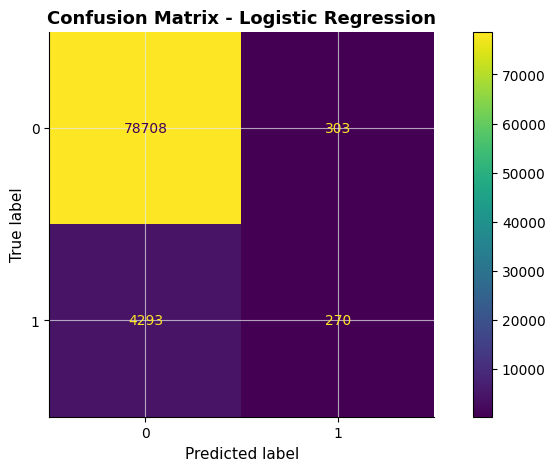

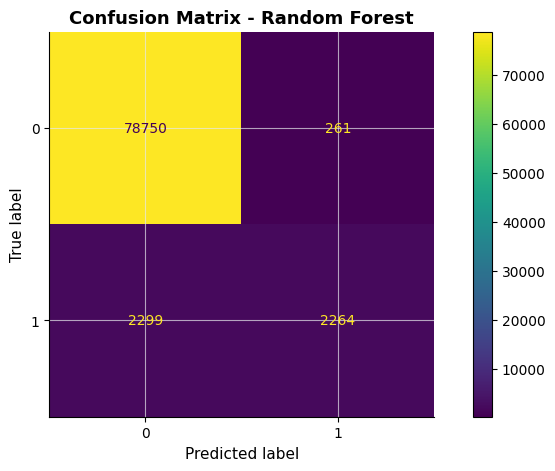

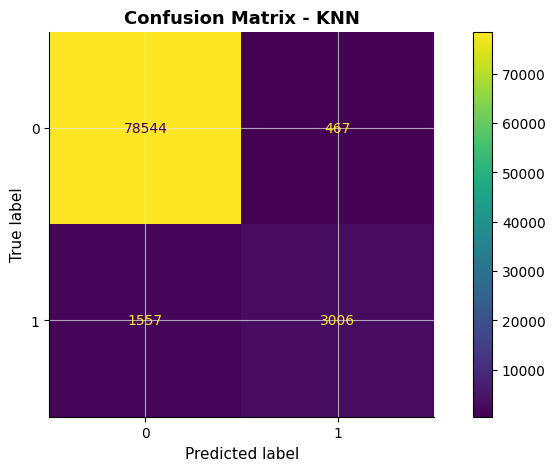

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.9450     0.9222  0.9450    0.9243
1        Random Forest    0.9694     0.9675  0.9694    0.9652
2                  KNN    0.9758     0.9743  0.9758    0.9742


In [ ]:
for col in X_train.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

# Train at least 3 models

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

results = []


for name, model in models.items():


    model.fit(X_train, y_train)


    y_pred = model.predict(X_test)

# For each model report: accuracy, precision, recall, F1-score
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Plot a confusion matrix for each model

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

    plt.title(f"Confusion Matrix - {name}")
    plt.show()
# Put all results in one summary table and choose the best model — explain your choice
results_df = pd.DataFrame(results)
print(results_df)


# Task 2.1: Build and Train

Epoch 1/45
10447/10447 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.9430 - loss: 1.6449 - val_accuracy: 0.9423 - val_loss: 0.2063
Epoch 2/45
10447/10447 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.9469 - loss: 0.2001 - val_accuracy: 0.9423 - val_loss: 0.2245
Epoch 3/45
10447/10447 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.9469 - loss: 0.1980 - val_accuracy: 0.9423 - val_loss: 0.2002
Epoch 4/45
10447/10447 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9469 - loss: 0.1950 - val_accuracy: 0.9423 - val_loss: 0.1988
Epoch 5/45
10447/10447 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.9469 - loss: 0.1891 - val_accuracy: 0.9423 - val_loss: 0.1986
Epoch 6/45
10447/10447 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.9469 - loss: 0.1868 - val_accuracy: 0.9423 - val_loss: 0.1970
Epoch 7/45
10447/10447 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.9466 - loss: 0.1833 - val_accuracy: 0.9415 - val_loss: 0.1942
Epoch 8/45
10447/10447 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 

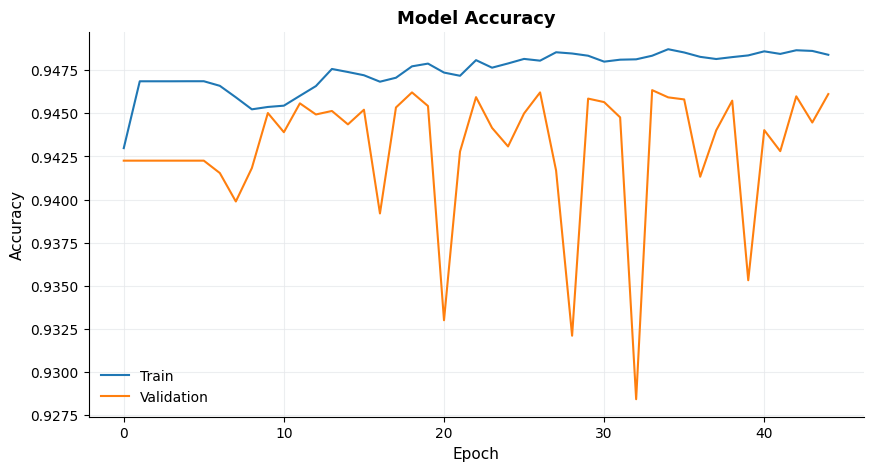

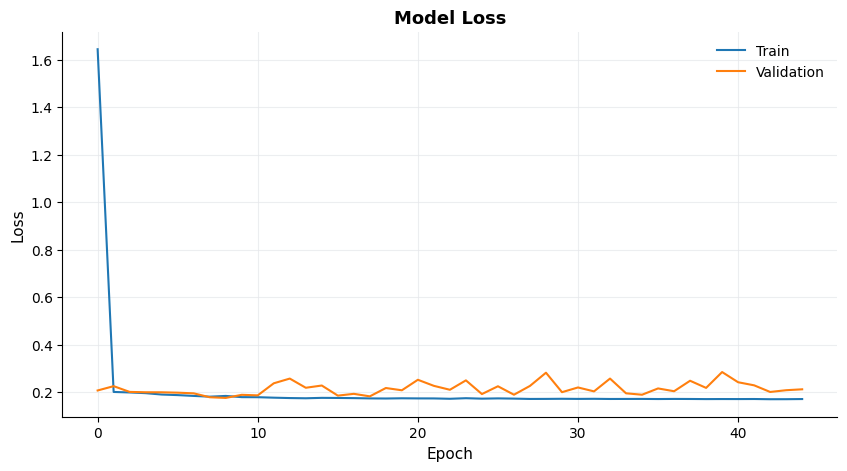

In [ ]:
# Build a neural network using Keras Dense layers with ReLU and Sigmoid/Softmax
model=Sequential([
    Dense(6, activation="relu", input_shape=(21,)),
# Add at least one Dropout layer to reduce overfitting
    Dropout(0.3),
    Dense(6, activation="relu"),
    Dense(1, activation="sigmoid")

])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


for col in X.columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))
# Train for at least 10 epochs
training = model.fit( X, y,epochs=45,  validation_split=0.2,verbose=1)

#Plot the training vs. validation loss and accuracy curves
plt.plot(training.history['accuracy'])
plt.plot(training.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'])
plt.show()


plt.plot(training.history['loss'])
plt.plot(training.history['val_loss'])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'])
plt.show()

# Task 2.2 - Compare with Step 1

2612/2612 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
0.9224040969679566
0.023313492063492064
0.010300241069471838
0.014287885696914424
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.9450     0.9222  0.9450    0.9243
1        Random Forest    0.9694     0.9675  0.9694    0.9652
2                  KNN    0.9758     0.9743  0.9758    0.9742
3       Neural Network    0.9224     0.0233  0.0103    0.0143
4       Neural Network    0.9224     0.0233  0.0103    0.0143
5       Neural Network    0.9224     0.0233  0.0103    0.0143


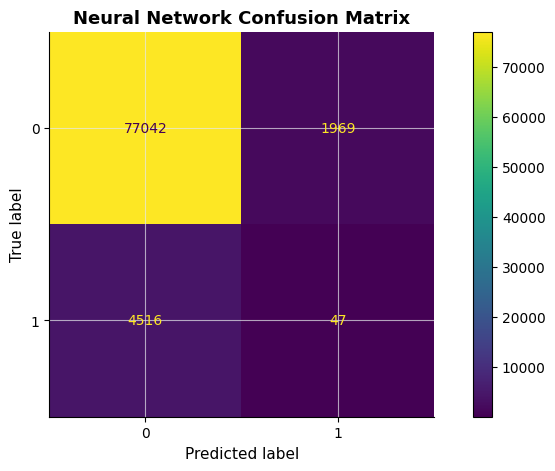

In [ ]:
# Evaluate the neural network on the test set using the same metrics as Step 1
y_pred_nn = (model.predict(X_test) > 0.5).astype("int32")

o_accuracy = accuracy_score(y_test, y_pred_nn)
lam_precision = precision_score(y_test, y_pred_nn)
la_recall = recall_score(y_test, y_pred_nn)
l_f1 = f1_score(y_test, y_pred_nn)

print(o_accuracy)
print(lam_precision)
print(la_recall)
print(l_f1)

# Add the neural network results to your summary table from Step 1
results.append({
    "Model": "Neural Network",
    "Accuracy": o_accuracy,
    "Precision": lam_precision,
    "Recall": la_recall,
    "F1-Score": l_f1
})

results_df = pd.DataFrame(results)
print(results_df)

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_nn)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Neural Network Confusion Matrix")
plt.show()



# Write 2–3 sentences explaining whether the neural network was better or worse and why


The neural network achieved lower performance compared to the other models  Although its accuracy was acceptable  its precision and recall were very low  which means it missed many positive cases  This indicates that the model was not effective at detecting important cases accurately
